# 💰📊 PDRB vs IPM — Provinsi Jawa Timur 2023

**Topik :** Apakah kekayaan ekonomi daerah berbanding lurus dengan kualitas hidup masyarakatnya?  
**Wilayah :** 38 Kabupaten/Kota Jawa Timur | **Tahun :** 2023  

**Input :**
| File | Kolom Wajib | Keterangan |
|---|---|---|
| `pdrb_jatim_2023.csv` | `Kab_Kota`, `PDRB_Juta` | PDRB ADHB per kapita (juta Rp) |
| `ipm_jatim_2023.csv` | `Kab_Kota`, `IPM`, `AHH`, `HLS`, `RLS`, `Pengeluaran` | Komponen IPM |

> **Sumber :** BPS Jawa Timur — [jatim.bps.go.id](https://jatim.bps.go.id) (download manual CSV)

---

## 📋 Alur Kerja
```
1.  Install & Import Library
2.  Upload & Load CSV
3.  Validasi & Cleaning Data
4.  Merge Dataset + Koordinat GPS
5.  Eksplorasi Statistik
6.  Visualisasi Seaborn
     6a. Bar Chart PDRB & IPM
     6b. Scatter Plot + Regresi
     6c. Quadrant Analysis
     6d. Heatmap Korelasi Komponen
7.  Peta Folium — Grafik Batang Mini HTML per Kab/Kota + Legenda
8.  Peta Folium — HeatMap PDRB
9.  Peta Folium — HeatMap IPM
10. Peta Folium — CircleMarker Dual Variabel (PDRB + IPM)
11. Peta Folium — Animasi Fly-To otomatis per Kab/Kota
12. Dashboard Ringkasan Interaktif (HTML)
13. Analisis Naratif & Insight
14. Export Semua Output
```


# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, json, io
warnings.filterwarnings('ignore')

import folium
from folium.plugins import HeatMap
import branca.colormap as cm

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('✅ Semua library siap')


✅ Semua library siap


# 2.Upload & Load CSV


Upload csv

**`pdrb_jatim_2023.csv`**
```
Kab_Kota,PDRB_Juta
Kota Surabaya,185432.5
Gresik,124876.3
```

**`ipm_jatim_2023.csv`**
```
Kab_Kota,IPM,AHH,HLS,RLS,Pengeluaran
Kota Surabaya,82.31,74.12,14.85,11.02,18250000
```


In [ ]:
from google.colab import files

print('📤 Upload pdrb_jatim_2023.csv dan ipm_jatim_2023.csv')
uploaded = files.upload()

def load_csv_from_upload(uploaded_dict, keyword):
    for fname, content in uploaded_dict.items():
        if keyword.lower() in fname.lower():
            df = pd.read_csv(io.BytesIO(content))
            print(f'✅ Loaded "{fname}" → {df.shape[0]} baris, kolom: {df.columns.tolist()}')
            return df
    raise FileNotFoundError(f'File "{keyword}" tidak ditemukan.')

df_pdrb = load_csv_from_upload(uploaded, 'pdrb')
df_ipm  = load_csv_from_upload(uploaded, 'ipm')


📤 Upload pdrb_jatim_2023.csv dan ipm_jatim_2023.csv


Saving ipm_jatim_2023.csv to ipm_jatim_2023.csv
Saving pdrb_jatim_2023.csv to pdrb_jatim_2023 (1).csv
✅ Loaded "pdrb_jatim_2023 (1).csv" → 42 baris, kolom: ['Kabupaten/Kota', 'Produk Domestik Regional Bruto per Kapita Atas Dasar Harga Berlaku (Ribu Rp)']
✅ Loaded "ipm_jatim_2023.csv" → 42 baris, kolom: ['Kabupaten/Kota', 'Indeks Pembangunan Manusia']


# 3. Cleaning Data

In [ ]:
# Pemetaan nama kolom sesuai dengan file yang diunggah
df_pdrb = df_pdrb.rename(columns={
    'Kabupaten/Kota': 'Kab_Kota',
    'Produk Domestik Regional Bruto per Kapita Atas Dasar Harga Berlaku (Ribu Rp)': 'PDRB_Juta'
})

df_ipm = df_ipm.rename(columns={
    'Kabupaten/Kota': 'Kab_Kota',
    'Indeks Pembangunan Manusia': 'IPM'
})

# Membersihkan spasi pada nama kolom dan data
df_pdrb.columns = df_pdrb.columns.str.strip()
df_ipm.columns  = df_ipm.columns.str.strip()

assert 'Kab_Kota'  in df_pdrb.columns, '❌ Kolom Kab_Kota tidak ada di PDRB'
assert 'PDRB_Juta' in df_pdrb.columns, '❌ Kolom PDRB_Juta tidak ada di PDRB'
assert 'Kab_Kota'  in df_ipm.columns,  '❌ Kolom Kab_Kota tidak ada di IPM'
assert 'IPM'        in df_ipm.columns,  '❌ Kolom IPM tidak ada di IPM'
print('✅ Kolom kunci OK')

df_pdrb['Kab_Kota'] = df_pdrb['Kab_Kota'].str.strip()
df_ipm['Kab_Kota']  = df_ipm['Kab_Kota'].str.strip()

# Konversi PDRB (dari Ribu Rp ke Juta Rp agar sesuai dengan visualisasi)
if 'PDRB_Juta' in df_pdrb.columns:
    df_pdrb['PDRB_Juta'] = pd.to_numeric(df_pdrb['PDRB_Juta'], errors='coerce') / 1000

for col in ['IPM','AHH','HLS','RLS','Pengeluaran']:
    if col in df_ipm.columns:
        df_ipm[col] = pd.to_numeric(df_ipm[col], errors='coerce')

print('\nMissing values PDRB:'); print(df_pdrb.isnull().sum().to_string())
print('\nMissing values IPM:');  print(df_ipm.isnull().sum().to_string())

only_pdrb = set(df_pdrb['Kab_Kota'].dropna()) - set(df_ipm['Kab_Kota'].dropna())
only_ipm  = set(df_ipm['Kab_Kota'].dropna())  - set(df_pdrb['Kab_Kota'].dropna())
if only_pdrb: print(f'\n⚠️  Hanya di PDRB: {only_pdrb}')
if only_ipm:  print(f'⚠️  Hanya di IPM : {only_ipm}')
if not only_pdrb and not only_ipm: print('\n✅ Nama kab/kota konsisten')

✅ Kolom kunci OK

Missing values PDRB:
Kab_Kota     1
PDRB_Juta    4

Missing values IPM:
Kab_Kota    1
IPM         3

⚠️  Hanya di PDRB: {'PDB Indonesia antara lain disebabkan oleh diskrepansi statistik.', 'Perbedaan antara jumlah PDRB 34 Provinsi dan'}
⚠️  Hanya di IPM : {'Jawa Timur', 'Indeks Pembangunan Manusia (IPM) 2020-2023 dihitung menggunakan Umur Harapan Hidup saat Lahir (UHH) hasil Long Form SP2020 (LF SP2020). IPM 2023 yang menggunakan UHH hasil SP2010 masih tersedia dan dapat diakses pada website BPS (www.bps.go.id)/<i>The 2020–2023 Human Development Index (HDI) was calculated using the Life Expectancy at Birth based on the Long Form 2020 Population Census. The 2023 HDI data using life expectancy based on the 2010 Population Census are still available at the BPS website (www.bps.go.id)</i>'}


# 4. 🔗 Merge Dataset + Koordinat GPS

In [ ]:
geo_coords = {
    'Pacitan':[-8.2104,111.0877],'Ponorogo':[-7.8677,111.4665],
    'Trenggalek':[-8.1706,111.7139],'Tulungagung':[-8.0658,111.9023],
    'Blitar':[-8.0953,112.1685],'Kediri':[-7.9480,112.0178],
    'Malang':[-8.1320,112.5714],'Lumajang':[-8.1333,113.2226],
    'Jember':[-8.1724,113.7026],'Banyuwangi':[-8.2192,114.3691],
    'Bondowoso':[-7.9165,113.8222],'Situbondo':[-7.7058,114.0136],
    'Probolinggo':[-7.7543,113.2159],'Pasuruan':[-7.6456,112.9023],
    'Sidoarjo':[-7.4458,112.7181],'Mojokerto':[-7.4712,111.5255],
    'Jombang':[-7.5461,112.2384],'Nganjuk':[-7.6048,111.9007],
    'Madiun':[-7.6298,111.5236],'Magetan':[-7.6435,111.3285],
    'Ngawi':[-7.4065,111.4459],'Bojonegoro':[-7.1514,111.8815],
    'Tuban':[-6.8997,112.0508],'Lamongan':[-7.1170,112.4155],
    'Gresik':[-7.1569,112.6550],'Bangkalan':[-7.0452,112.7442],
    'Sampang':[-7.1866,113.2458],'Pamekasan':[-7.1575,113.4711],
    'Sumenep':[-6.9741,113.8608],
    'Kota Kediri':[-7.8166,112.0114],'Kota Blitar':[-8.0953,112.1615],
    'Kota Malang':[-7.9797,112.6304],'Kota Probolinggo':[-7.7550,113.2149],
    'Kota Pasuruan':[-7.6450,112.9072],'Kota Mojokerto':[-7.4700,112.4332],
    'Kota Madiun':[-7.6298,111.5179],'Kota Surabaya':[-7.2575,112.7521],
    'Kota Batu':[-7.8695,112.5267],
}

df_coords = pd.DataFrame(
    [(k, v[0], v[1]) for k,v in geo_coords.items()],
    columns=['Kab_Kota','Lat','Lon']
)

df = df_pdrb.merge(df_ipm, on='Kab_Kota', how='inner')
df = df.merge(df_coords, on='Kab_Kota', how='left')

no_coords = df[df['Lat'].isna()]['Kab_Kota'].tolist()
if no_coords:
    print(f'⚠️  Tanpa koordinat: {no_coords}')
    print('   Cek kecocokan nama dengan kunci geo_coords di atas')

df.dropna(subset=['Lat','Lon','PDRB_Juta','IPM'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'✅ Merge selesai — {len(df)} kab/kota siap')
df.head()


⚠️  Tanpa koordinat: [nan, 'Catatan']
   Cek kecocokan nama dengan kunci geo_coords di atas
✅ Merge selesai — 38 kab/kota siap


,Kab_Kota,PDRB_Juta,IPM,Lat,Lon
0,Pacitan,33.149,70.94,-8.2104,111.0877
1,Ponorogo,26.314,73.18,-7.8677,111.4665
2,Trenggalek,30.681,71.96,-8.1706,111.7139
3,Tulungagung,43.297,74.65,-8.0658,111.9023
4,Blitar,35.812,72.84,-8.0953,112.1685


# 5. 📋 Eksplorasi Statistik

In [ ]:
print('═'*55)
print('STATISTIK DESKRIPTIF')
print('═'*55)
cols_show = [c for c in ['PDRB_Juta','IPM','AHH','HLS','RLS','Pengeluaran'] if c in df.columns]
display(df[cols_show].describe().round(2))

print(f'\n📌 PDRB tertinggi : {df.loc[df.PDRB_Juta.idxmax(),"Kab_Kota"]} ({df.PDRB_Juta.max():,.1f} juta Rp)')
print(f'📌 PDRB terendah  : {df.loc[df.PDRB_Juta.idxmin(),"Kab_Kota"]} ({df.PDRB_Juta.min():,.1f} juta Rp)')
print(f'📌 IPM tertinggi  : {df.loc[df.IPM.idxmax(),"Kab_Kota"]} (IPM {df.IPM.max():.2f})')
print(f'📌 IPM terendah   : {df.loc[df.IPM.idxmin(),"Kab_Kota"]} (IPM {df.IPM.min():.2f})')

corr = df['PDRB_Juta'].corr(df['IPM'])
print(f'\n📌 Korelasi Pearson PDRB vs IPM : r = {corr:.3f}')
if   corr >= 0.7:  print('   → Korelasi KUAT positif')
elif corr >= 0.4:  print('   → Korelasi SEDANG positif')
elif corr >= 0:    print('   → Korelasi LEMAH positif')
else:              print('   → Korelasi NEGATIF')


═══════════════════════════════════════════════════════
STATISTIK DESKRIPTIF
═══════════════════════════════════════════════════════


,PDRB_Juta,IPM
count,38.00,38.00
mean,70.66,74.68
std,89.45,4.71
min,23.84,66.19
25%,31.98,71.06
50%,37.23,73.90
75%,72.48,77.96
max,541.07,84.00



📌 PDRB tertinggi : Kota Kediri (541.1 juta Rp)
📌 PDRB terendah  : Pamekasan (23.8 juta Rp)
📌 IPM tertinggi  : Kota Malang (IPM 84.00)
📌 IPM terendah   : Sampang (IPM 66.19)

📌 Korelasi Pearson PDRB vs IPM : r = 0.499
   → Korelasi SEDANG positif


# 6. 📊 Visualisasi Seaborn

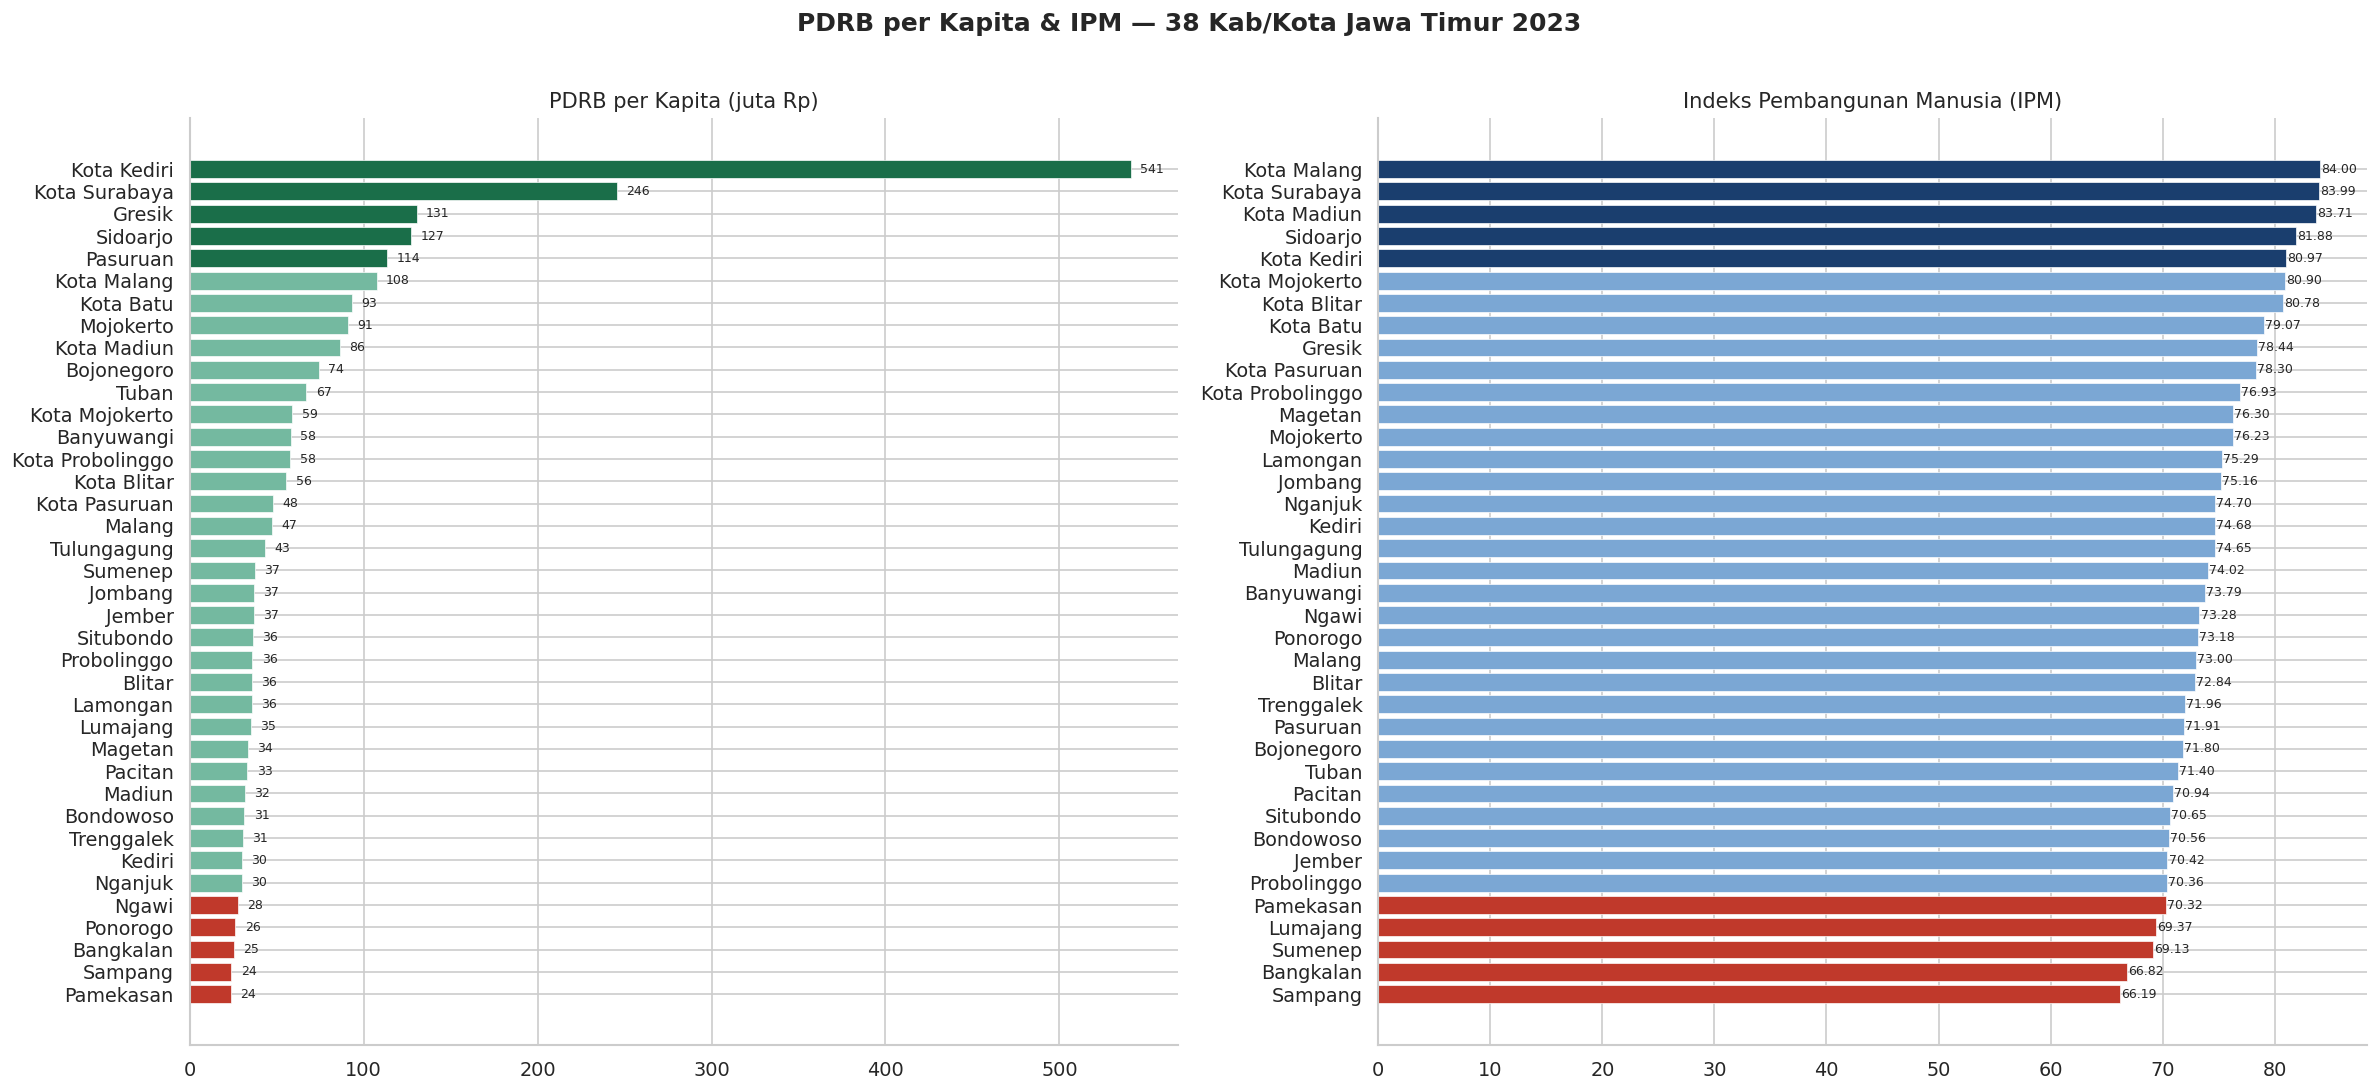

In [ ]:
# 6a ── Bar Chart PDRB & IPM Berdampingan ─────────────────────────────────
df_sp = df.sort_values('PDRB_Juta', ascending=False)
df_si = df.sort_values('IPM',       ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('PDRB per Kapita & IPM — 38 Kab/Kota Jawa Timur 2023',
             fontsize=15, fontweight='bold', y=1.01)

pal_p = ['#1a6e49' if i<5 else ('#c0392b' if i>=len(df)-5 else '#74b9a0') for i in range(len(df_sp))]
bars = axes[0].barh(df_sp['Kab_Kota'], df_sp['PDRB_Juta'], color=pal_p, edgecolor='white', lw=0.4)
axes[0].set_title('PDRB per Kapita (juta Rp)'); axes[0].invert_yaxis()
for bar, val in zip(bars, df_sp['PDRB_Juta']):
    axes[0].text(val + df_sp['PDRB_Juta'].max()*0.01,
                 bar.get_y()+bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=7.5)
axes[0].spines[['top','right']].set_visible(False)

pal_i = ['#1a3e6e' if i<5 else ('#c0392b' if i>=len(df)-5 else '#7ba7d4') for i in range(len(df_si))]
bars2 = axes[1].barh(df_si['Kab_Kota'], df_si['IPM'], color=pal_i, edgecolor='white', lw=0.4)
axes[1].set_title('Indeks Pembangunan Manusia (IPM)'); axes[1].invert_yaxis()
for bar, val in zip(bars2, df_si['IPM']):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=7.5)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()


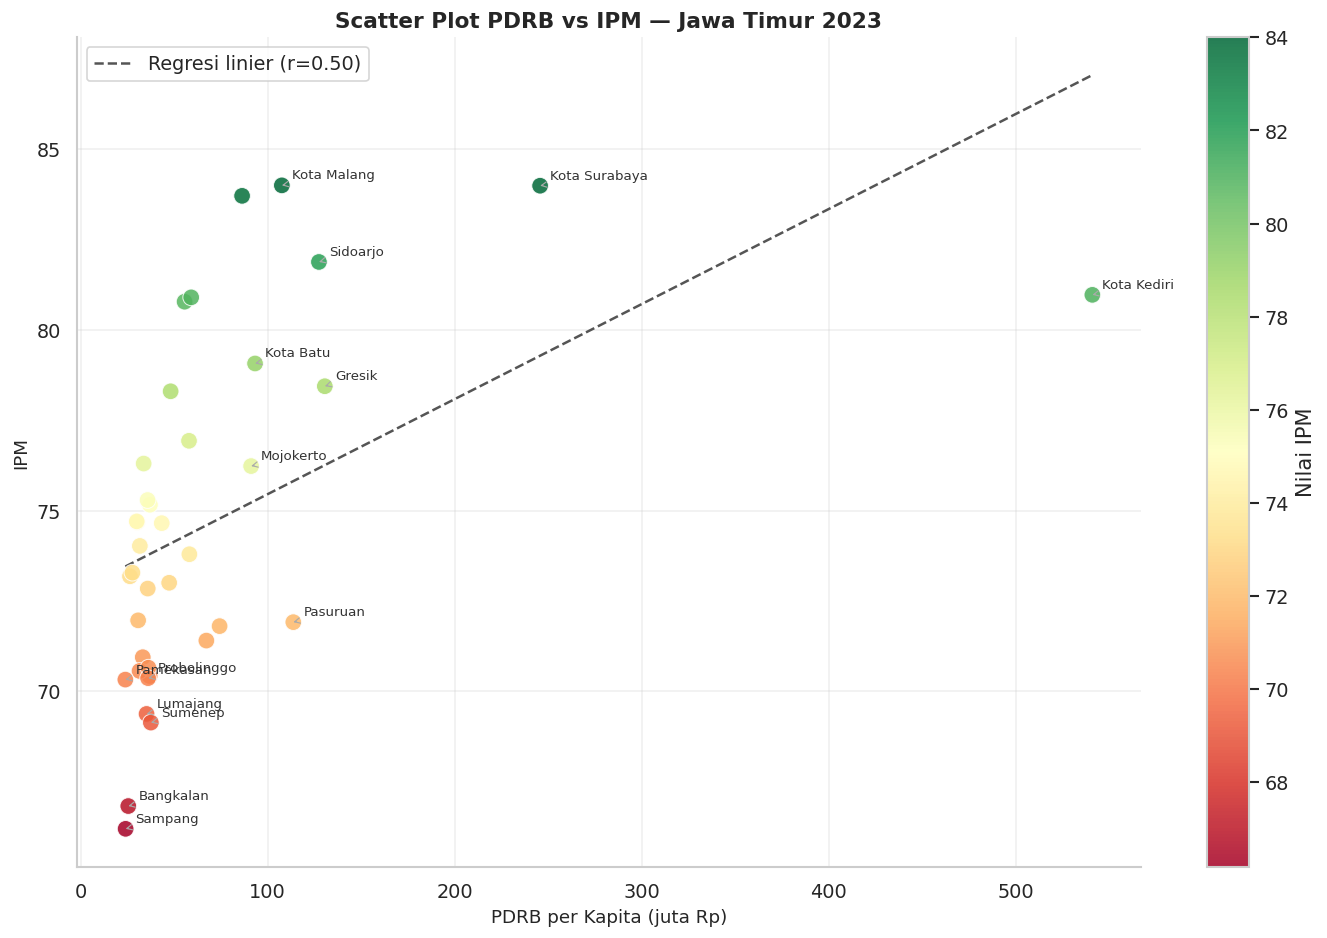

In [ ]:
# 6b ── Scatter Plot PDRB vs IPM + Regresi ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(df['PDRB_Juta'], df['IPM'],
                c=df['IPM'], cmap='RdYlGn', s=100,
                alpha=0.85, edgecolors='white', lw=0.6, zorder=3)
plt.colorbar(sc, ax=ax, label='Nilai IPM')

m_r, b_r = np.polyfit(df['PDRB_Juta'], df['IPM'], 1)
xr = np.linspace(df['PDRB_Juta'].min(), df['PDRB_Juta'].max(), 100)
ax.plot(xr, m_r*xr+b_r, '--', color='#555', lw=1.5,
        label=f'Regresi linier (r={df["PDRB_Juta"].corr(df["IPM"]):.2f})')

thr_p = df['PDRB_Juta'].quantile(0.80)
thr_i = df['IPM'].quantile(0.15)
for _, row in df.iterrows():
    if row['PDRB_Juta'] > thr_p or row['IPM'] < thr_i:
        ax.annotate(row['Kab_Kota'],
                    xy=(row['PDRB_Juta'], row['IPM']),
                    xytext=(6,4), textcoords='offset points',
                    fontsize=8, color='#333',
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.7))

ax.set_xlabel('PDRB per Kapita (juta Rp)', fontsize=11)
ax.set_ylabel('IPM', fontsize=11)
ax.set_title('Scatter Plot PDRB vs IPM — Jawa Timur 2023', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


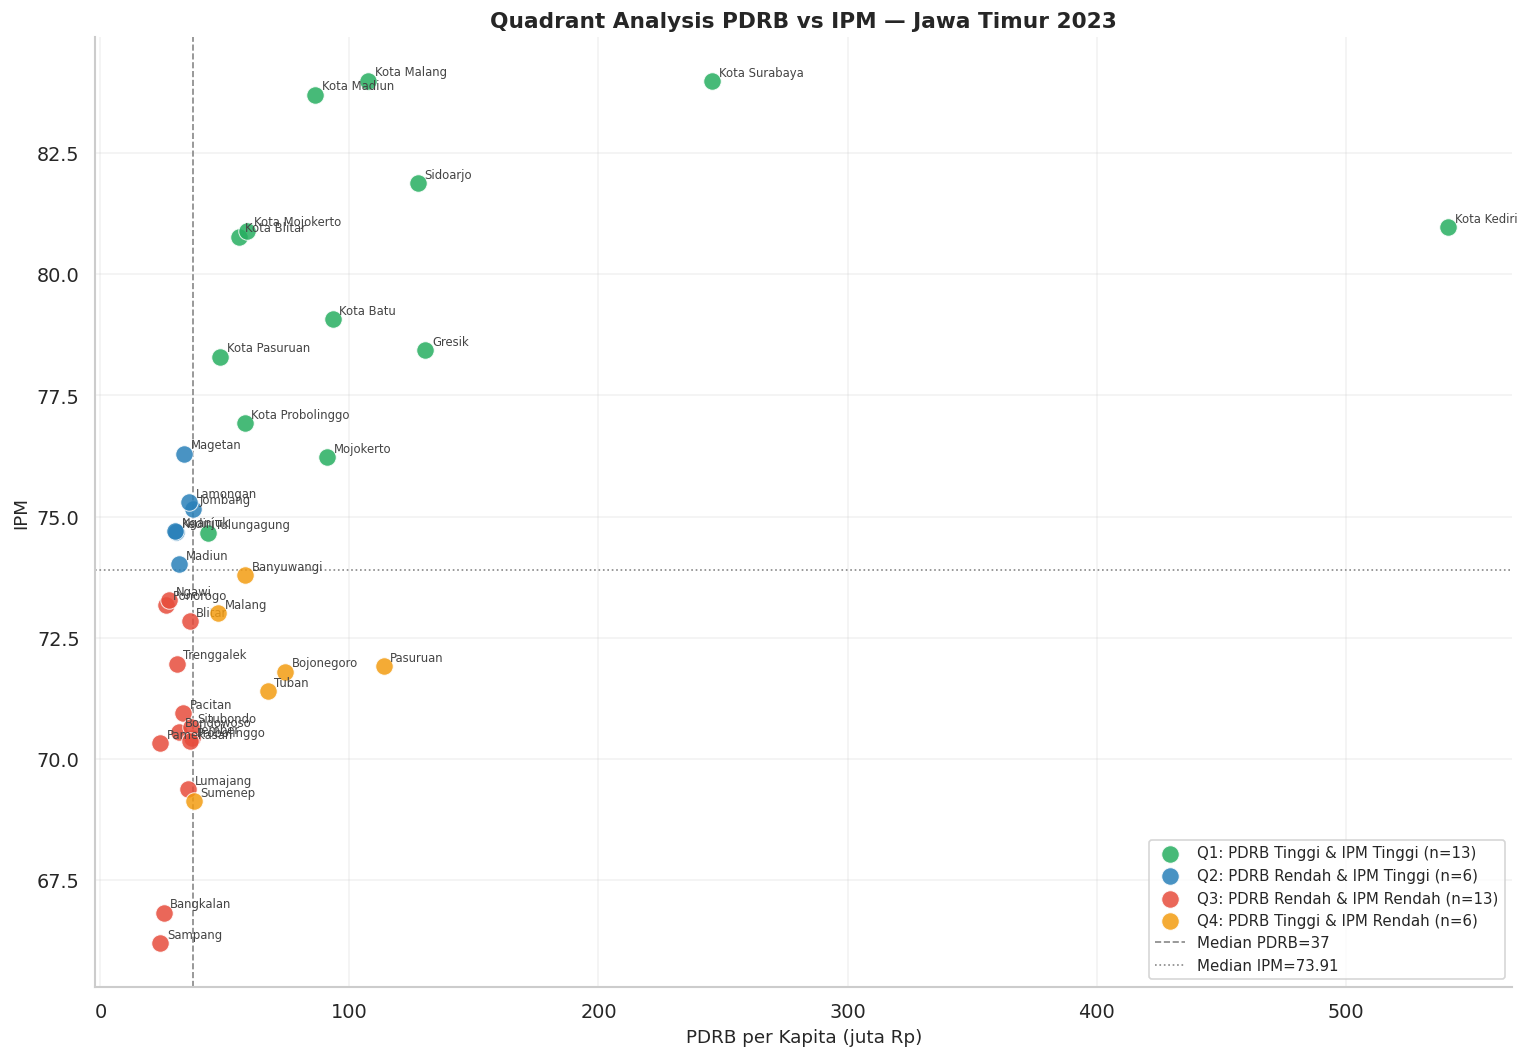


📊 Distribusi Kuadran:
Kuadran
Q3: PDRB Rendah & IPM Rendah    13
Q1: PDRB Tinggi & IPM Tinggi    13
Q2: PDRB Rendah & IPM Tinggi     6
Q4: PDRB Tinggi & IPM Rendah     6


In [ ]:
# 6c ── Quadrant Analysis ─────────────────────────────────────────────────
med_p = df['PDRB_Juta'].median()
med_i = df['IPM'].median()

def get_q(row):
    if   row['PDRB_Juta']>=med_p and row['IPM']>=med_i: return 'Q1: PDRB Tinggi & IPM Tinggi'
    elif row['PDRB_Juta']< med_p and row['IPM']>=med_i: return 'Q2: PDRB Rendah & IPM Tinggi'
    elif row['PDRB_Juta']< med_p and row['IPM']< med_i: return 'Q3: PDRB Rendah & IPM Rendah'
    else:                                                return 'Q4: PDRB Tinggi & IPM Rendah'

df['Kuadran'] = df.apply(get_q, axis=1)
CQ = {'Q1: PDRB Tinggi & IPM Tinggi':'#27ae60',
      'Q2: PDRB Rendah & IPM Tinggi':'#2980b9',
      'Q3: PDRB Rendah & IPM Rendah':'#e74c3c',
      'Q4: PDRB Tinggi & IPM Rendah':'#f39c12'}

fig, ax = plt.subplots(figsize=(13, 9))
for q, grp in df.groupby('Kuadran'):
    ax.scatter(grp['PDRB_Juta'], grp['IPM'],
               color=CQ[q], label=f'{q} (n={len(grp)})',
               s=110, alpha=0.85, edgecolors='white', lw=0.6, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['Kab_Kota'], xy=(row['PDRB_Juta'],row['IPM']),
                    xytext=(4,3), textcoords='offset points', fontsize=7, color='#444')

ax.axvline(med_p, color='#888', ls='--', lw=1, label=f'Median PDRB={med_p:,.0f}')
ax.axhline(med_i, color='#888', ls=':',  lw=1, label=f'Median IPM={med_i:.2f}')
ax.set_xlabel('PDRB per Kapita (juta Rp)',fontsize=11)
ax.set_ylabel('IPM',fontsize=11)
ax.set_title('Quadrant Analysis PDRB vs IPM — Jawa Timur 2023',fontsize=13,fontweight='bold')
ax.legend(loc='lower right',fontsize=9)
ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('\n📊 Distribusi Kuadran:')
print(df['Kuadran'].value_counts().to_string())


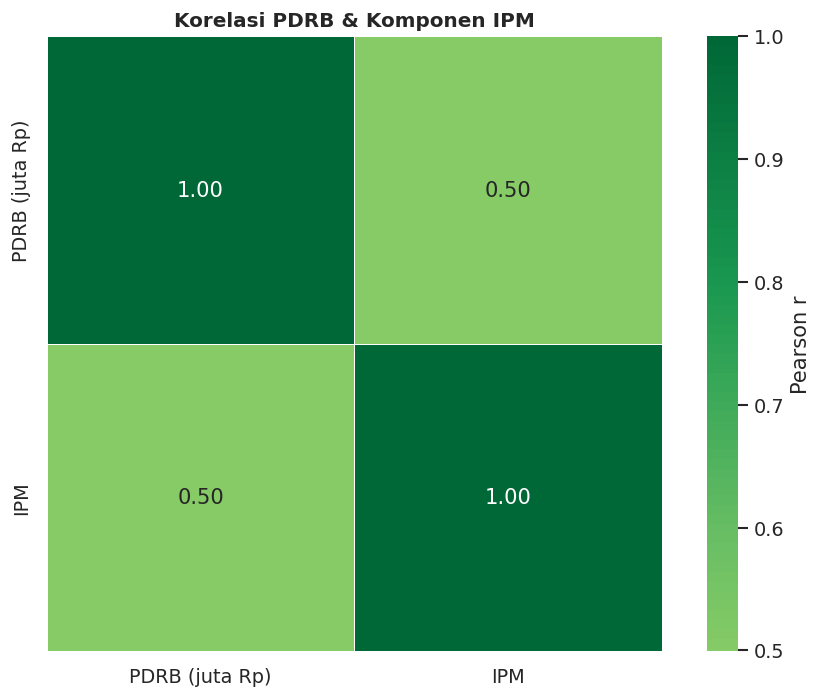

In [ ]:
# 6d ── Heatmap Korelasi Komponen IPM vs PDRB ──────────────────────────────
cols_c = [c for c in ['PDRB_Juta','IPM','AHH','HLS','RLS','Pengeluaran'] if c in df.columns]
lbl = {'PDRB_Juta':'PDRB (juta Rp)','IPM':'IPM',
       'AHH':'Angka Harapan Hidup','HLS':'Harapan Lama Sekolah',
       'RLS':'Rata-rata Lama Sekolah','Pengeluaran':'Pengeluaran/Kapita'}

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[cols_c].rename(columns=lbl).corr(),
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Korelasi PDRB & Komponen IPM', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


# 7. 📊 Peta Folium — Grafik Batang Mini HTML per Kab/Kota

Setiap marker menampilkan **mini bar chart** langsung di peta:  
- Batang **hijau** → nilai PDRB per kapita (juta Rp)  
- Batang **biru** → nilai IPM  
- Angka tampil di atas setiap batang  
- Legenda di pojok kiri bawah  


In [ ]:
pdrb_min_v = df['PDRB_Juta'].min()
pdrb_max_v = df['PDRB_Juta'].max()
ipm_min_v  = df['IPM'].min()
ipm_max_v  = df['IPM'].max()

# Skala tinggi batang: normalisasi ke max 55px
BAR_MAX_PX = 55

m_bars = folium.Map(location=[-7.75, 112.7], zoom_start=8, tiles='CartoDB positron')

targets = []  # untuk animasi fly-to di section 11

for _, row in df.iterrows():
    lat, lon = row['Lat'], row['Lon']
    targets.append({'name': row['Kab_Kota'], 'coords': [lat, lon]})

    # Normalisasi tinggi batang
    h_pdrb = max(4, (row['PDRB_Juta'] - pdrb_min_v) / (pdrb_max_v - pdrb_min_v + 1e-9) * BAR_MAX_PX)
    h_ipm  = max(4, (row['IPM'] - ipm_min_v)         / (ipm_max_v  - ipm_min_v  + 1e-9) * BAR_MAX_PX)

    # Label ringkas di atas batang
    l_pdrb = f'{row["PDRB_Juta"]:.0f}'
    l_ipm  = f'{row["IPM"]:.1f}'

    # Kuadran badge warna
    q_colors = {
        'Q1: PDRB Tinggi & IPM Tinggi': '#27ae60',
        'Q2: PDRB Rendah & IPM Tinggi': '#2980b9',
        'Q3: PDRB Rendah & IPM Rendah': '#e74c3c',
        'Q4: PDRB Tinggi & IPM Rendah': '#f39c12',
    }
    q_val   = row.get('Kuadran', '')
    q_color = q_colors.get(q_val, '#888')

    bar_html = f"""
    <div style="width:110px;text-align:center;font-family:Arial;">
      <div style="display:flex;align-items:flex-end;justify-content:center;
                  height:70px;gap:6px;background:rgba(255,255,255,0.92);
                  padding:6px 8px 4px 8px;border-radius:6px;
                  border:1px solid #ddd;box-shadow:0 1px 4px rgba(0,0,0,.15);">
        <div style="display:flex;flex-direction:column;align-items:center;">
          <span style="font-size:5.5pt;font-weight:bold;color:#1a6e49;white-space:nowrap">{l_pdrb}</span>
          <div style="width:14px;height:{h_pdrb:.1f}px;background:#1a9850;
                      border-radius:2px 2px 0 0;"></div>
        </div>
        <div style="display:flex;flex-direction:column;align-items:center;">
          <span style="font-size:5.5pt;font-weight:bold;color:#1a3e6e;">{l_ipm}</span>
          <div style="width:14px;height:{h_ipm:.1f}px;background:#2980b9;
                      border-radius:2px 2px 0 0;"></div>
        </div>
      </div>
      <div style="font-size:7pt;font-weight:bold;margin-top:3px;color:#222;
                  background:white;border-radius:3px;padding:1px 3px;
                  border-left:3px solid {q_color};
                  text-align:left;line-height:1.3;">
        {row['Kab_Kota']}
      </div>
    </div>
    """

    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            icon_size=(110, 95),
            icon_anchor=(55, 95),
            html=bar_html
        )
    ).add_to(m_bars)

# ── LEGENDA ───────────────────────────────────────────────────────────────
legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
            background:white;padding:12px 16px;border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,.2);
            font-family:Arial;font-size:12px;min-width:190px;">
  <b style="font-size:13px">📊 Grafik Batang Mini</b><br><br>
  <div style="display:flex;align-items:center;gap:6px;margin-bottom:5px">
    <div style="width:14px;height:14px;background:#1a9850;border-radius:2px"></div>
    <span>PDRB per Kapita (juta Rp)</span>
  </div>
  <div style="display:flex;align-items:center;gap:6px;margin-bottom:10px">
    <div style="width:14px;height:14px;background:#2980b9;border-radius:2px"></div>
    <span>IPM (0–100)</span>
  </div>
  <hr style="margin:6px 0">
  <b>Kuadran</b><br>
  <span style="border-left:3px solid #27ae60;padding-left:5px">Q1 PDRB ↑ IPM ↑</span><br>
  <span style="border-left:3px solid #2980b9;padding-left:5px">Q2 PDRB ↓ IPM ↑</span><br>
  <span style="border-left:3px solid #e74c3c;padding-left:5px">Q3 PDRB ↓ IPM ↓</span><br>
  <span style="border-left:3px solid #f39c12;padding-left:5px">Q4 PDRB ↑ IPM ↓</span>
</div>'''
m_bars.get_root().html.add_child(folium.Element(legend_html))

title_html = '''
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
            z-index:9999;background:white;padding:10px 22px;border-radius:8px;
            box-shadow:0 2px 10px rgba(0,0,0,.18);font-family:Arial;
            font-size:13px;font-weight:bold;">
  📊 Grafik Batang Mini PDRB & IPM — Jawa Timur 2023
</div>'''
m_bars.get_root().html.add_child(folium.Element(title_html))

print(f'✅ Peta bar chart: {len(df)} marker ditambahkan')
m_bars


✅ Peta bar chart: 38 marker ditambahkan


# 8. 🌡️ Peta HeatMap — Intensitas PDRB

In [ ]:
def base_map():
    return folium.Map(location=[-7.75, 112.7], zoom_start=8, tiles='CartoDB positron')

def add_title(m, text):
    html = f'''<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
        z-index:9999;background:white;padding:10px 22px;border-radius:8px;
        box-shadow:0 2px 10px rgba(0,0,0,.18);font-family:Arial;
        font-size:13px;font-weight:bold">{text}</div>'''
    m.get_root().html.add_child(folium.Element(html))

m_heat_pdrb = base_map()
HeatMap(
    df[['Lat','Lon','PDRB_Juta']].values.tolist(),
    min_opacity=0.3, radius=35, blur=25,
    gradient={0.2:'#313695',0.45:'#74add1',0.65:'#fee090',0.85:'#f46d43',1.0:'#a50026'},
    name='HeatMap PDRB'
).add_to(m_heat_pdrb)
add_title(m_heat_pdrb, '🌡️ HeatMap PDRB per Kapita — Jawa Timur 2023')
m_heat_pdrb


# 9. 🌡️ Peta HeatMap — Intensitas IPM

In [ ]:
m_heat_ipm = base_map()
HeatMap(
    df[['Lat','Lon','IPM']].values.tolist(),
    min_opacity=0.3, radius=35, blur=25,
    gradient={0.2:'#d73027',0.5:'#fee08b',0.8:'#1a9850',1.0:'#006837'},
    name='HeatMap IPM'
).add_to(m_heat_ipm)
add_title(m_heat_ipm, '🌡️ HeatMap IPM — Jawa Timur 2023')
m_heat_ipm


# 10. 📍 Peta CircleMarker — Dual Variabel

- **Ukuran** → proporsional PDRB per kapita  
- **Warna** → gradasi nilai IPM (merah → kuning → hijau)  
- **Tooltip** → detail kedua variabel + semua komponen IPM  


In [ ]:
cmap_ipm = cm.LinearColormap(
    colors=['#d73027','#fee08b','#1a9850'],
    vmin=df['IPM'].min(), vmax=df['IPM'].max(),
    caption='Nilai IPM 2023'
)

m_circle = base_map()
cmap_ipm.add_to(m_circle)

for _, row in df.iterrows():
    radius = 5 + (row['PDRB_Juta'] - pdrb_min_v) / (pdrb_max_v - pdrb_min_v + 1e-9) * 22
    color  = cmap_ipm(row['IPM'])

    komp = ''
    for col, lbl in [('AHH','Angka Harapan Hidup'),('HLS','Harapan Lama Sekolah'),
                     ('RLS','Rata-rata Lama Sekolah'),('Pengeluaran','Pengeluaran/Kapita')]:
        if col in df.columns and pd.notna(row.get(col)):
            val = f'Rp {int(row[col]):,}' if col=='Pengeluaran' else f'{row[col]:.2f}'
            komp += f'<tr><td style="color:#777">{lbl}</td><td><b>{val}</b></td></tr>'

    tt = f'''
    <div style="font-family:Arial;font-size:12px;min-width:210px">
      <b style="font-size:13px">{row['Kab_Kota']}</b>
      <hr style="margin:4px 0">
      <table style="width:100%;border-collapse:collapse">
        <tr><td style="color:#777">PDRB/Kapita</td>
            <td><b>Rp {row['PDRB_Juta']:,.1f} juta</b></td></tr>
        <tr><td style="color:#777">IPM</td><td><b>{row['IPM']:.2f}</b></td></tr>
        <tr><td style="color:#777">Kuadran</td><td><b>{row.get('Kuadran','—')}</b></td></tr>
        {komp}
      </table></div>'''

    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=radius, color=color,
        fill=True, fill_color=color, fill_opacity=0.8,
        tooltip=folium.Tooltip(tt, sticky=True)
    ).add_to(m_circle)

legend_size = '''
<div style="position:fixed;bottom:30px;left:20px;z-index:9999;
            background:white;padding:12px 16px;border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,.18);font-family:Arial;font-size:11px">
  <b>Ukuran</b> = PDRB (besar = tinggi)<br>
  <b>Warna</b><br>
  <span style="color:#1a9850">⬤</span> IPM Tinggi &nbsp;
  <span style="color:#d73027">⬤</span> IPM Rendah
</div>'''
m_circle.get_root().html.add_child(folium.Element(legend_size))
add_title(m_circle, '📍 PDRB (ukuran) & IPM (warna) — Jawa Timur 2023')
m_circle


# 11. 🎬 Peta Animasi — Fly-To Otomatis per Kab/Kota

Peta akan **terbang otomatis** dari satu kab/kota ke kab/kota berikutnya secara berulang:  
- Setiap stop: zoom-in ke kab/kota, tampilkan grafik batang mini PDRB & IPM  
- Perpindahan: animasi `flyTo` dengan durasi 2.5 detik  
- Loop otomatis kembali ke awal setelah semua kab/kota selesai  
- Tidak perlu interaksi — langsung berjalan setelah 3 detik peta dimuat  


In [ ]:
# ── BANGUN PETA ANIMASI ────────────────────────────────────────────────────
m_anim = folium.Map(location=[-7.75, 112.7], zoom_start=8, tiles='CartoDB positron')

# ── TAMBAHKAN GRAFIK BATANG MINI KE SETIAP MARKER ─────────────────────────
targets_anim = []

for _, row in df.iterrows():
    lat, lon = row['Lat'], row['Lon']
    targets_anim.append({'name': row['Kab_Kota'], 'coords': [lat, lon]})

    h_pdrb = max(4, (row['PDRB_Juta'] - pdrb_min_v) / (pdrb_max_v - pdrb_min_v + 1e-9) * BAR_MAX_PX)
    h_ipm  = max(4, (row['IPM'] - ipm_min_v)         / (ipm_max_v  - ipm_min_v  + 1e-9) * BAR_MAX_PX)
    l_pdrb = f'{row["PDRB_Juta"]:.0f}'
    l_ipm  = f'{row["IPM"]:.1f}'

    q_colors = {
        'Q1: PDRB Tinggi & IPM Tinggi':'#27ae60',
        'Q2: PDRB Rendah & IPM Tinggi':'#2980b9',
        'Q3: PDRB Rendah & IPM Rendah':'#e74c3c',
        'Q4: PDRB Tinggi & IPM Rendah':'#f39c12',
    }
    q_color = q_colors.get(row.get('Kuadran',''), '#888')

    bar_html = f"""
    <div style="width:110px;text-align:center;font-family:Arial;">
      <div style="display:flex;align-items:flex-end;justify-content:center;
                  height:70px;gap:6px;background:rgba(255,255,255,0.92);
                  padding:6px 8px 4px 8px;border-radius:6px;
                  border:1px solid #ddd;box-shadow:0 1px 4px rgba(0,0,0,.15);">
        <div style="display:flex;flex-direction:column;align-items:center;">
          <span style="font-size:5.5pt;font-weight:bold;color:#1a6e49;">{l_pdrb}</span>
          <div style="width:14px;height:{h_pdrb:.1f}px;background:#1a9850;border-radius:2px 2px 0 0;"></div>
        </div>
        <div style="display:flex;flex-direction:column;align-items:center;">
          <span style="font-size:5.5pt;font-weight:bold;color:#1a3e6e;">{l_ipm}</span>
          <div style="width:14px;height:{h_ipm:.1f}px;background:#2980b9;border-radius:2px 2px 0 0;"></div>
        </div>
      </div>
      <div style="font-size:7pt;font-weight:bold;margin-top:3px;color:#222;
                  background:white;border-radius:3px;padding:1px 3px;
                  border-left:3px solid {q_color};text-align:left;line-height:1.3;">
        {row['Kab_Kota']}
      </div>
    </div>
    """
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(icon_size=(110,95), icon_anchor=(55,95), html=bar_html)
    ).add_to(m_anim)

# ── SCRIPT JAVASCRIPT FLY-TO OTOMATIS LOOPING ─────────────────────────────
targets_js = json.dumps(targets_anim)
script = f"""
<script>
var targets = {targets_js};
var i = 0;

function nextCity() {{
    var map = {m_anim.get_name()};
    if (i >= targets.length) {{ i = 0; }}

    // Info panel kota aktif
    var info = document.getElementById('city-info');
    if (info) {{ info.innerText = '📍 ' + targets[i].name; }}

    map.flyTo(targets[i].coords, 11, {{
        animate: true,
        duration: 2.5
    }});
    i++;
    setTimeout(nextCity, 5000);
}}

// Mulai setelah 3 detik peta dimuat
setTimeout(nextCity, 3000);
</script>
"""
m_anim.get_root().html.add_child(folium.Element(script))

# ── INFO PANEL NAMA KOTA AKTIF ─────────────────────────────────────────────
info_panel = '''
<div id="city-info" style="position:fixed;top:60px;left:50%;
     transform:translateX(-50%);z-index:9999;
     background:rgba(30,30,30,0.82);color:white;
     padding:7px 20px;border-radius:20px;
     font-family:Arial;font-size:13px;font-weight:bold;
     box-shadow:0 2px 8px rgba(0,0,0,.3);
     pointer-events:none;">
  ✈️ Memuat animasi...
</div>'''
m_anim.get_root().html.add_child(folium.Element(info_panel))

# ── LEGENDA ────────────────────────────────────────────────────────────────
legend_anim = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
            background:white;padding:12px 16px;border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,.2);font-family:Arial;font-size:12px;">
  <b>📊 Grafik Batang Mini</b><br><br>
  <div style="display:flex;align-items:center;gap:6px;margin-bottom:5px">
    <div style="width:14px;height:14px;background:#1a9850;border-radius:2px"></div>
    <span>PDRB per Kapita (juta Rp)</span>
  </div>
  <div style="display:flex;align-items:center;gap:6px;margin-bottom:10px">
    <div style="width:14px;height:14px;background:#2980b9;border-radius:2px"></div>
    <span>IPM (0–100)</span>
  </div>
  <hr style="margin:6px 0">
  <b>Kuadran (garis samping label)</b><br>
  <span style="border-left:3px solid #27ae60;padding-left:5px">Q1 PDRB ↑ IPM ↑ (Maju)</span><br>
  <span style="border-left:3px solid #2980b9;padding-left:5px">Q2 PDRB ↓ IPM ↑</span><br>
  <span style="border-left:3px solid #e74c3c;padding-left:5px">Q3 PDRB ↓ IPM ↓ (Perlu Perhatian)</span><br>
  <span style="border-left:3px solid #f39c12;padding-left:5px">Q4 PDRB ↑ IPM ↓ (Anomali)</span><br><br>
  <i style="font-size:11px;color:#888">✈️ Peta terbang otomatis tiap 5 detik</i>
</div>'''
m_anim.get_root().html.add_child(folium.Element(legend_anim))

title_anim = '''
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
            z-index:9999;background:white;padding:10px 22px;border-radius:8px;
            box-shadow:0 2px 10px rgba(0,0,0,.18);font-family:Arial;
            font-size:13px;font-weight:bold;">
  🎬 Animasi Fly-To PDRB & IPM — Jawa Timur 2023 (Auto-loop)
</div>'''
m_anim.get_root().html.add_child(folium.Element(title_anim))

print(f'✅ Peta animasi siap — {len(targets_anim)} kab/kota, loop otomatis')
m_anim


✅ Peta animasi siap — 38 kab/kota, loop otomatis


# 12. 🖥️ Dashboard Ringkasan Interaktif

Render ringkasan statistik dan distribusi kuadran sebagai **dashboard HTML** yang bisa
disimpan sebagai file terpisah atau ditampilkan langsung di Colab via `IPython.display`.


In [ ]:
from IPython.display import HTML

# ── HITUNG STATISTIK UNTUK DASHBOARD ──────────────────────────────────────
q_counts = df['Kuadran'].value_counts().to_dict()
q_total  = len(df)

def q_pct(key):
    return q_counts.get(key, 0) / q_total * 100

top3_pdrb = df.nlargest(3, 'PDRB_Juta')[['Kab_Kota','PDRB_Juta']].values.tolist()
bot3_pdrb = df.nsmallest(3,'PDRB_Juta')[['Kab_Kota','PDRB_Juta']].values.tolist()
top3_ipm  = df.nlargest(3, 'IPM')[['Kab_Kota','IPM']].values.tolist()
bot3_ipm  = df.nsmallest(3,'IPM')[['Kab_Kota','IPM']].values.tolist()

corr_pdrb_ipm = df['PDRB_Juta'].corr(df['IPM'])

def rank_rows(data, fmt):
    return ''.join([f'<tr><td style="padding:2px 8px;">{r[0]}</td>'
                    f'<td style="padding:2px 8px;text-align:right"><b>{r[1]:{fmt}}</b></td></tr>'
                    for r in data])

dashboard_html = f"""
<div style="font-family:Arial;max-width:900px;margin:0 auto;padding:20px;">

  <!-- JUDUL -->
  <div style="background:linear-gradient(135deg,#1a6e49,#1a3e6e);color:white;
              padding:20px 28px;border-radius:12px;margin-bottom:20px;">
    <h2 style="margin:0;font-size:20px">💰📊 Dashboard PDRB vs IPM — Jawa Timur 2023</h2>
    <p style="margin:6px 0 0;opacity:0.85;font-size:13px">
      {q_total} Kabupaten/Kota &nbsp;|&nbsp;
      Korelasi Pearson r = <b>{corr_pdrb_ipm:.3f}</b> &nbsp;|&nbsp;
      Rata-rata PDRB = <b>Rp {df['PDRB_Juta'].mean():,.1f} juta</b> &nbsp;|&nbsp;
      Rata-rata IPM = <b>{df['IPM'].mean():.2f}</b>
    </p>
  </div>

  <!-- KUADRAN CARDS -->
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:20px;">
    {chr(10).join([f'''
    <div style="background:{bg};color:white;padding:14px;border-radius:10px;text-align:center">
      <div style="font-size:22px;font-weight:bold">{q_counts.get(q,0)}</div>
      <div style="font-size:11px;margin-top:4px;opacity:0.9">{q.split(':')[1].strip()}</div>
      <div style="font-size:10px;margin-top:2px;opacity:0.75">{q_pct(q):.1f}% kab/kota</div>
    </div>'''
    for q, bg in [
        ('Q1: PDRB Tinggi & IPM Tinggi','#27ae60'),
        ('Q2: PDRB Rendah & IPM Tinggi','#2980b9'),
        ('Q3: PDRB Rendah & IPM Rendah','#e74c3c'),
        ('Q4: PDRB Tinggi & IPM Rendah','#f39c12'),
    ]])}
  </div>

  <!-- RANKING TABLES -->
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">

    <div style="background:#f8f9fa;border-radius:10px;padding:16px;">
      <b>🏆 Top 3 PDRB per Kapita</b>
      <table style="width:100%;margin-top:8px;font-size:13px">
        {rank_rows(top3_pdrb, ',.1f')}
      </table>
      <hr style="margin:10px 0">
      <b>⬇️ Bottom 3 PDRB per Kapita</b>
      <table style="width:100%;margin-top:8px;font-size:13px">
        {rank_rows(bot3_pdrb, ',.1f')}
      </table>
    </div>

    <div style="background:#f8f9fa;border-radius:10px;padding:16px;">
      <b>🏆 Top 3 IPM</b>
      <table style="width:100%;margin-top:8px;font-size:13px">
        {rank_rows(top3_ipm, '.2f')}
      </table>
      <hr style="margin:10px 0">
      <b>⬇️ Bottom 3 IPM</b>
      <table style="width:100%;margin-top:8px;font-size:13px">
        {rank_rows(bot3_ipm, '.2f')}
      </table>
    </div>

  </div>

  <!-- DISTRIBUSI BAR -->
  <div style="background:#f8f9fa;border-radius:10px;padding:16px;margin-top:16px;">
    <b>📊 Distribusi PDRB per Kapita (ribu Rp)</b>
    <div style="display:flex;align-items:flex-end;gap:3px;height:60px;margin-top:10px;">
      {''.join([f'<div title="{row["Kab_Kota"]}: Rp {row["PDRB_Juta"]:,.1f}jt" style="flex:1;background:#1a9850;opacity:0.7;height:{max(4,(row["PDRB_Juta"]-pdrb_min_v)/(pdrb_max_v-pdrb_min_v+1e-9)*56+4):.1f}px;border-radius:2px 2px 0 0;"></div>' for _,row in df.sort_values('PDRB_Juta').iterrows()])}
    </div>
    <div style="font-size:10px;color:#888;margin-top:4px;">← rendah &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; tinggi →</div>
  </div>

</div>
"""

# Tampilkan di Colab
display(HTML(dashboard_html))

# Simpan ke file
with open('dashboard_PDRB_IPM_jatim2023.html', 'w', encoding='utf-8') as f:
    f.write(dashboard_html)
print('✅ Dashboard tersimpan: dashboard_PDRB_IPM_jatim2023.html')


Kota Kediri,541.1
Kota Surabaya,245.7
Gresik,130.5
Pamekasan,23.8
Sampang,24.0
Bangkalan,25.4
Kota Malang,84.00
Kota Surabaya,83.99
Kota Madiun,83.71
Sampang,66.19
Bangkalan,66.82


✅ Dashboard tersimpan: dashboard_PDRB_IPM_jatim2023.html


# 13. 🔍 Analisis Naratif & Insight


In [ ]:
# ── GENERATE ANALISIS OTOMATIS ────────────────────────────────────────────
corr = df['PDRB_Juta'].corr(df['IPM'])
q_cnt = df['Kuadran'].value_counts().to_dict()

kota_pdrb_top = df.loc[df['PDRB_Juta'].idxmax(), 'Kab_Kota']
kota_pdrb_bot = df.loc[df['PDRB_Juta'].idxmin(), 'Kab_Kota']
kota_ipm_top  = df.loc[df['IPM'].idxmax(),  'Kab_Kota']
kota_ipm_bot  = df.loc[df['IPM'].idxmin(),  'Kab_Kota']

# Anomali: PDRB tinggi tapi IPM rendah (Q4)
q4 = df[df['Kuadran']=='Q4: PDRB Tinggi & IPM Rendah']['Kab_Kota'].tolist()
# Perlu perhatian: dua rendah (Q3)
q3 = df[df['Kuadran']=='Q3: PDRB Rendah & IPM Rendah']['Kab_Kota'].tolist()

print('═'*65)
print('ANALISIS NARATIF — PDRB vs IPM JAWA TIMUR 2023')
print('═'*65)

print(f"""
1. KORELASI UMUM
   Korelasi Pearson antara PDRB per kapita dan IPM adalah r = {corr:.3f}.
   {'Ini menunjukkan korelasi KUAT positif — daerah dengan PDRB tinggi' if corr>=0.7
    else 'Ini menunjukkan korelasi SEDANG positif — ada pola umum namun' if corr>=0.4
    else 'Korelasi lemah — PDRB tinggi tidak selalu'}
   cenderung memiliki IPM yang lebih tinggi pula.

2. DISPARITAS
   PDRB tertinggi  : {kota_pdrb_top} (Rp {df.loc[df.PDRB_Juta.idxmax(),'PDRB_Juta']:,.1f} juta)
   PDRB terendah   : {kota_pdrb_bot} (Rp {df.loc[df.PDRB_Juta.idxmin(),'PDRB_Juta']:,.1f} juta)
   Rasio disparitas PDRB: {df.PDRB_Juta.max()/df.PDRB_Juta.min():.1f}x

   IPM tertinggi   : {kota_ipm_top} ({df.loc[df.IPM.idxmax(),'IPM']:.2f})
   IPM terendah    : {kota_ipm_bot} ({df.loc[df.IPM.idxmin(),'IPM']:.2f})
   Selisih IPM     : {df.IPM.max()-df.IPM.min():.2f} poin

3. DISTRIBUSI KUADRAN
   Q1 Maju & Sejahtera   : {q_cnt.get('Q1: PDRB Tinggi & IPM Tinggi',0)} kab/kota
   Q2 Sejahtera, Ekonomi Belum Optimal : {q_cnt.get('Q2: PDRB Rendah & IPM Tinggi',0)} kab/kota
   Q3 Perlu Perhatian     : {q_cnt.get('Q3: PDRB Rendah & IPM Rendah',0)} kab/kota
   Q4 Anomali (kaya, IPM rendah) : {q_cnt.get('Q4: PDRB Tinggi & IPM Rendah',0)} kab/kota

4. ANOMALI (Q4 — PDRB TINGGI, IPM RENDAH)
   {', '.join(q4) if q4 else 'Tidak ada'}
   → Daerah ini memiliki output ekonomi tinggi namun kesejahteraan
     masyarakat belum merata. Perlu ditelusuri faktor struktural:
     dominasi sektor ekstraktif, tenaga kerja dari luar daerah,
     atau distribusi pendapatan yang timpang.

5. DAERAH PRIORITAS (Q3 — PDRB RENDAH & IPM RENDAH)
   {', '.join(q3) if q3 else 'Tidak ada'}
   → Daerah ini membutuhkan intervensi kebijakan ganda:
     peningkatan aktivitas ekonomi sekaligus layanan dasar
     (pendidikan, kesehatan, daya beli).
""")


═════════════════════════════════════════════════════════════════
ANALISIS NARATIF — PDRB vs IPM JAWA TIMUR 2023
═════════════════════════════════════════════════════════════════

1. KORELASI UMUM
   Korelasi Pearson antara PDRB per kapita dan IPM adalah r = 0.499.
   Ini menunjukkan korelasi SEDANG positif — ada pola umum namun
   cenderung memiliki IPM yang lebih tinggi pula.

2. DISPARITAS
   PDRB tertinggi  : Kota Kediri (Rp 541.1 juta)
   PDRB terendah   : Pamekasan (Rp 23.8 juta)
   Rasio disparitas PDRB: 22.7x

   IPM tertinggi   : Kota Malang (84.00)
   IPM terendah    : Sampang (66.19)
   Selisih IPM     : 17.81 poin

3. DISTRIBUSI KUADRAN
   Q1 Maju & Sejahtera   : 13 kab/kota
   Q2 Sejahtera, Ekonomi Belum Optimal : 6 kab/kota
   Q3 Perlu Perhatian     : 13 kab/kota
   Q4 Anomali (kaya, IPM rendah) : 6 kab/kota

4. ANOMALI (Q4 — PDRB TINGGI, IPM RENDAH)
   Malang, Banyuwangi, Pasuruan, Bojonegoro, Tuban, Sumenep
   → Daerah ini memiliki output ekonomi tinggi namun kesejahter

# 14. 💾 Export Semua Output

In [ ]:
from google.colab import files

output_maps = {
    'peta_bar_chart_mini_jatim2023.html':   m_bars,
    'peta_heatmap_PDRB_jatim2023.html':     m_heat_pdrb,
    'peta_heatmap_IPM_jatim2023.html':      m_heat_ipm,
    'peta_circlemarker_dual_jatim2023.html': m_circle,
    'peta_animasi_flyto_jatim2023.html':    m_anim,
}

for fname, peta in output_maps.items():
    peta.save(fname)
    print(f'✅ Peta tersimpan : {fname}')

print('✅ Dashboard tersimpan: dashboard_PDRB_IPM_jatim2023.html')

print('\n📥 Mendownload semua file...')
for fname in list(output_maps.keys()) + ['dashboard_PDRB_IPM_jatim2023.html']:
    files.download(fname)
print('✅ Selesai!')


---

# 📝 Panduan Kustomisasi

| Yang Ingin Diubah | Cara |
|---|---|
| Nama kolom CSV berbeda | Edit `rename(columns={...})` di Section 3 |
| Tinggi batang maksimal | Ganti `BAR_MAX_PX` di Section 7 |
| Warna batang PDRB/IPM | Ganti `background:#1a9850` / `#2980b9` di bar_html |
| Durasi animasi fly-to | Ganti `duration: 2.5` di script JS Section 11 |
| Interval antar kota | Ganti `setTimeout(nextCity, 5000)` (ms) Section 11 |
| Tambah variabel ke bar | Tambah batang ke bar_html, sesuaikan `icon_size` |
| Provinsi lain | Ganti `geo_coords` Section 4, update koordinat |

## 🔗 Unduh Data BPS Jawa Timur
- PDRB per kapita: https://jatim.bps.go.id → Tabel Statis → Ekonomi → PDRB
- IPM dan komponen: https://jatim.bps.go.id → Tabel Statis → Sosial → IPM
